=== STEP 1: DATA LOADING & CLEANING ===
Dataset Successfully Loaded. Shape: 3900 rows, 18 columns.

Missing Values Check:
Review Rating    37
dtype: int64

Duplicate Rows Found: 0

Data Types Summary:
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object

=== STEP 2: EXPLORATORY DATA ANALYSIS (EDA) ===

Descriptive Statistics for Numerical Features:
                        count         mean          std   min     25%     50

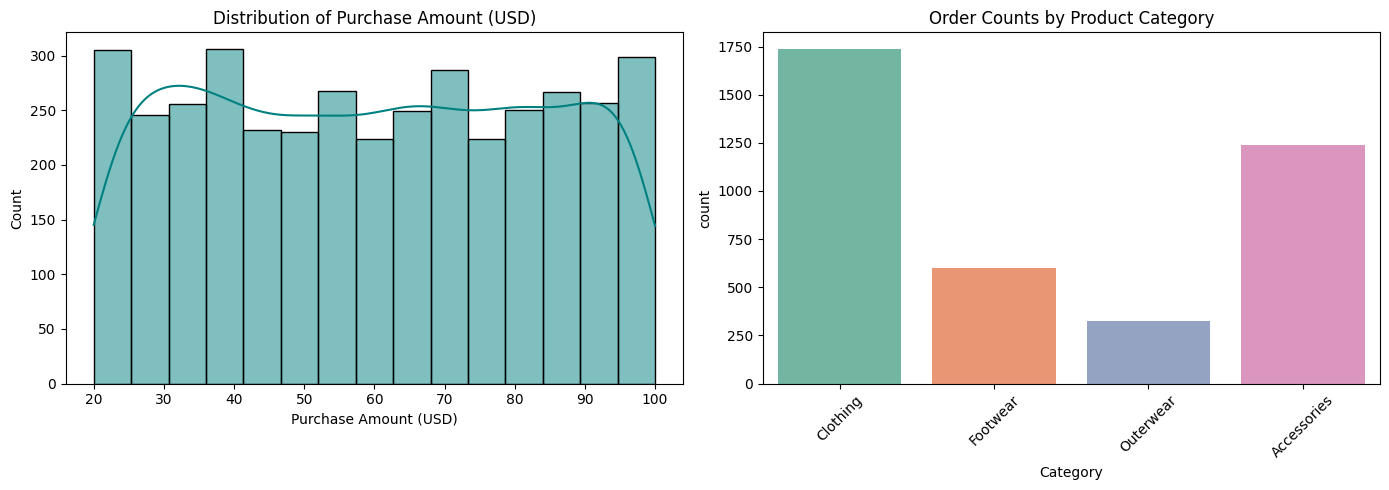


=== STEP 3: ADVANCED FEATURE ENGINEERING ===
Engineered Metrics Distributions:
        value_tier  dependency_score  satisfaction_flag
399      Low-Value                 2                  0
487   Medium-Value                 2                  1
2911  Medium-Value                 0                  0
3608     Low-Value                 0                  1
260      Low-Value                 2                  0

=== STEP 4: THE LOYALTY DEBATE (COMPETING DEFINITIONS) ===
Total Customers Identified by Definition A (Organic): 1529
Total Customers Identified by Definition B (Monetary): 1762

Evaluating Definitions against Business Realities:
                Metric  Definition A (Organic)  Definition B (Monetary)
   Avg Estimated Spend              2047.60170              2254.115778
     Avg Review Rating                 3.77155                 3.757406
Promo Dependency Score                 0.00000                 1.406924

=== STEP 5: EXPORTING CLEANED AND ENGINEERED DATA ===
Pipeline C

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# STEP 1: DATA LOADING, CLEANING & SANITY CHECKS

print("=== STEP 1: DATA LOADING & CLEANING ===")

# Load dataset
df = pd.read_csv('Dataset.csv')
print(f"Dataset Successfully Loaded. Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

# 1. Clean Column Names (Strip trailing spaces if any)
df.columns = df.columns.str.strip()

# 2. Check for Missing Values
missing_count = df.isnull().sum()
print("Missing Values Check:")
print(missing_count[missing_count > 0] if missing_count.sum() > 0 else "No missing values found! Data is complete.")

# 3. Check and Remove Duplicates
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed successfully.")

# 4. Data Type Standarization & Value Uniformity
# Strip whitespaces from categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

print("\nData Types Summary:")
print(df.dtypes)


# -------------------------------------------------------------------------
# STEP 2: DEEP EXPLORATORY DATA ANALYSIS (EDA)
# -------------------------------------------------------------------------
print("\n=== STEP 2: EXPLORATORY DATA ANALYSIS (EDA) ===")

# 1. High-Level Statistical Summary
print("\nDescriptive Statistics for Numerical Features:")
print(df.describe().T)

# 2. Revenue Dependency Analysis (Baseline Promotion Impact)
promo_revenue = df.groupby('Promo Code Used')['Purchase Amount (USD)'].sum()
promo_counts = df['Promo Code Used'].value_counts()
print("\nPromotion Dependency Baseline:")
for status in ['Yes', 'No']:
    rev_pct = (promo_revenue[status] / df['Purchase Amount (USD)'].sum()) * 100
    cnt_pct = (promo_counts[status] / len(df)) * 100
    print(f"Promo Used: {status} -> Responsible for {rev_pct:.2f}% of Revenue ({cnt_pct:.2f}% of Transactions)")

# 3. Visualizations (Distribution of Spend and Ratings)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Purchase Amount (USD)'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Purchase Amount (USD)')

sns.countplot(x='Category', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Order Counts by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------
# STEP 3: ADVANCED FEATURE ENGINEERING (CONSULTING METRICS)
# -------------------------------------------------------------------------
print("\n=== STEP 3: ADVANCED FEATURE ENGINEERING ===")

# A. VALUE TIER (Monetary Value Proxy)
# Formula: Current Purchase Amount * (Previous Purchases + 1) to estimate total historical value
df['Total_Estimated_Spend'] = df['Purchase Amount (USD)'] * (df['Previous Purchases'] + 1)

# Categorizing using strict percentiles (30th and 75th) to divide the customer pyramid
q30 = df['Total_Estimated_Spend'].quantile(0.30)
q75 = df['Total_Estimated_Spend'].quantile(0.75)

def segment_value_tier(spend):
    if spend <= q30: return 'Low-Value'
    elif spend <= q75: return 'Medium-Value'
    else: return 'High-Value'

df['value_tier'] = df['Total_Estimated_Spend'].apply(segment_value_tier)


# B. PROMO DEPENDENCY SCORE (Scale 0 to 3)
# Measuring reliance on discount behavior
def evaluate_promo_dependency(row):
    score = 0
    # Condition 1: Direct Promo/Discount usage in current transaction
    if row['Promo Code Used'] == 'Yes' or row['Discount Applied'] == 'Yes':
        score += 2
    # Condition 2: Frequent shoppers who aren't loyalty subscribers but pull discounts
    if row['Subscription Status'] == 'No' and score > 0:
        if row['Frequency of Purchases'] in ['Weekly', 'Bi-Weekly', 'Fortnightly', 'Monthly']:
            score += 1
    return score

df['dependency_score'] = df.apply(evaluate_promo_dependency, axis=1)


# C. SATISFACTION FLAG (Binary Proxy for Brand Health)
# Review rating >= 4.0 indicates a highly satisfied/promoter customer
df['satisfaction_flag'] = np.where(df['Review Rating'] >= 4.0, 1, 0)

print("Engineered Metrics Distributions:")
print(df[['value_tier', 'dependency_score', 'satisfaction_flag']].sample(5))


# -------------------------------------------------------------------------
# STEP 4: THE LOYALTY DEBATE & STATISTICAL TESTING
# -------------------------------------------------------------------------
print("\n=== STEP 4: THE LOYALTY DEBATE (COMPETING DEFINITIONS) ===")

# Definition A: FREQUENCY & ORGANIC DRIVEN (The Pure Loyalist)
# Customers with high repeat history (Previous Purchases > 15) who did NOT use a discount code this time.
df['Loyalty_Def_A'] = np.where((df['Previous Purchases'] > 15) & (df['Promo Code Used'] == 'No'), 1, 0)

# Definition B: VALUE & ENGAGEMENT DRIVEN (The Big Spender / Subscriber)
# Customers who fall into the High-Value Tier OR are active Paid Subscribers.
df['Loyalty_Def_B'] = np.where((df['value_tier'] == 'High-Value') | (df['Subscription Status'] == 'Yes'), 1, 0)

# STATISTICAL VALIDATION & COMPARISON
print(f"Total Customers Identified by Definition A (Organic): {df['Loyalty_Def_A'].sum()}")
print(f"Total Customers Identified by Definition B (Monetary): {df['Loyalty_Def_B'].sum()}")

# Testing Internal Consistency: Correlation with Revenue and Satisfaction
print("\nEvaluating Definitions against Business Realities:")

metrics_comparison = {
    "Metric": ["Avg Estimated Spend", "Avg Review Rating", "Promo Dependency Score"],
    "Definition A (Organic)": [
        df[df['Loyalty_Def_A'] == 1]['Total_Estimated_Spend'].mean(),
        df[df['Loyalty_Def_A'] == 1]['Review Rating'].mean(),
        df[df['Loyalty_Def_A'] == 1]['dependency_score'].mean()
    ],
    "Definition B (Monetary)": [
        df[df['Loyalty_Def_B'] == 1]['Total_Estimated_Spend'].mean(),
        df[df['Loyalty_Def_B'] == 1]['Review Rating'].mean(),
        df[df['Loyalty_Def_B'] == 1]['dependency_score'].mean()
    ]
}

comp_df = pd.DataFrame(metrics_comparison)
print(comp_df.to_string(index=False))


# -------------------------------------------------------------------------
# STEP 5: FINAL DATA EXPORT
# -------------------------------------------------------------------------
print("\n=== STEP 5: EXPORTING CLEANED AND ENGINEERED DATA ===")
df.to_csv('engineered_customer_data.csv', index=False)
print("Pipeline Complete! File saved as 'engineered_customer_data.csv' for SQL & Power BI layers.")

# STEP 1: DATA LOADING, CLEANING & SANITY CHECKS

In [2]:
df = pd.read_csv('Dataset.csv')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns.\n")

Shape: 3900 rows, 18 columns.



In [3]:
df.columns = df.columns.str.strip()

In [7]:
missing_count = df.isnull().sum()

In [8]:
missing_count

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [11]:
duplicate_count = df.duplicated().sum()

In [12]:
duplicate_count

np.int64(0)

In [13]:
if duplicate_count > 0:
    df = df.drop_duplicates()

# 4. Data Type Standarization & Value Uniformity
# Strip whitespaces from categorical variables


In [14]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].str.strip()

In [16]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


# STEP 2: DEEP EXPLORATORY DATA ANALYSIS (EDA)

In [18]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer ID,3900.0,1950.500000,1125.977353,1.0,975.75,1950.5,2925.25,3900.0
Age,3900.0,44.068462,15.207589,18.0,31.00,44.0,57.00,70.0
Purchase Amount (USD),3900.0,59.764359,23.685392,20.0,39.00,60.0,81.00,100.0
Review Rating,3863.0,3.750065,0.716983,2.5,3.10,3.8,4.40,5.0
Previous Purchases,3900.0,25.351538,14.447125,1.0,13.00,25.0,38.00,50.0


## Revenue Dependency Analysis (Baseline Promotion Impact)

In [20]:
promo_revenue = df.groupby('Promo Code Used')['Purchase Amount (USD)'].sum()
promo_counts = df['Promo Code Used'].value_counts()
for status in ['Yes', 'No']:
    rev_pct = (promo_revenue[status] / df['Purchase Amount (USD)'].sum()) * 100
    cnt_pct = (promo_counts[status] / len(df)) * 100
    print(f"Promo Used: {status} -> Responsible for {rev_pct:.2f}% of Revenue ({cnt_pct:.2f}% of Transactions)")

Promo Used: Yes -> Responsible for 42.65% of Revenue (43.00% of Transactions)
Promo Used: No -> Responsible for 57.35% of Revenue (57.00% of Transactions)


## 3. Visualizations (Distribution of Spend and Ratings)

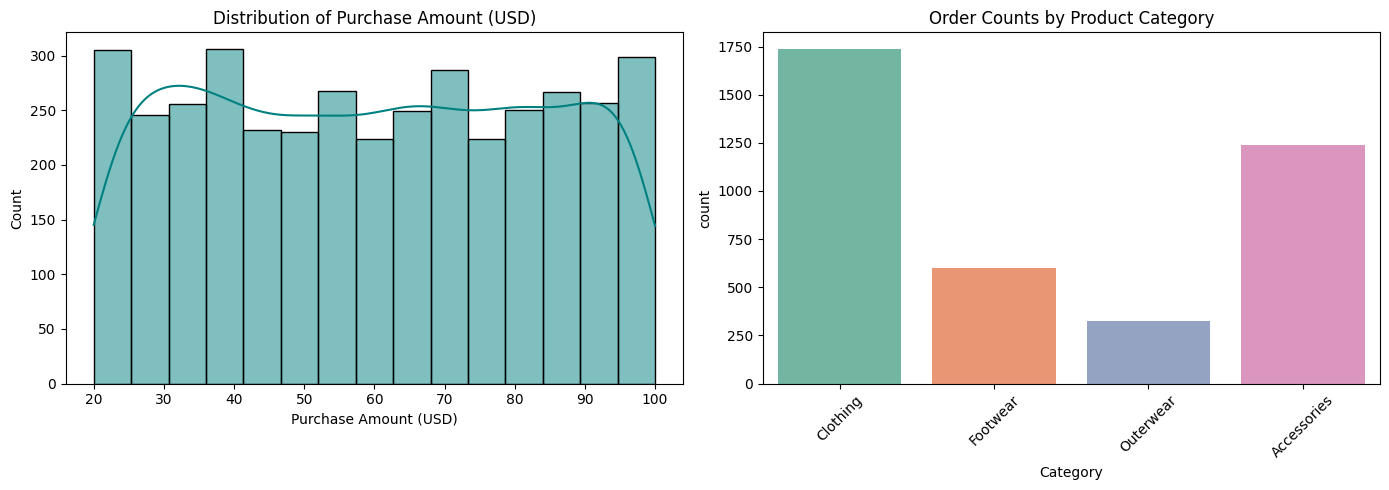

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Purchase Amount (USD)'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Purchase Amount (USD)')

sns.countplot(x='Category', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Order Counts by Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# STEP 3: ADVANCED FEATURE ENGINEERING (CONSULTING METRICS)

In [22]:
df['Total_Estimated_Spend'] = df['Purchase Amount (USD)'] * (df['Previous Purchases'] + 1)
q30 = df['Total_Estimated_Spend'].quantile(0.30)
q75 = df['Total_Estimated_Spend'].quantile(0.75)
def segment_value_tier(spend):
    if spend <= q30: return 'Low-Value'
    elif spend <= q75: return 'Medium-Value'
    else: return 'High-Value'
df['value_tier'] = df['Total_Estimated_Spend'].apply(segment_value_tier)

In [23]:
def evaluate_promo_dependency(row):
    score = 0
    # Condition 1: Direct Promo/Discount usage in current transaction
    if row['Promo Code Used'] == 'Yes' or row['Discount Applied'] == 'Yes':
        score += 2
    # Condition 2: Frequent shoppers who aren't loyalty subscribers but pull discounts
    if row['Subscription Status'] == 'No' and score > 0:
        if row['Frequency of Purchases'] in ['Weekly', 'Bi-Weekly', 'Fortnightly', 'Monthly']:
            score += 1
    return score

df['dependency_score'] = df.apply(evaluate_promo_dependency, axis=1)

In [24]:
df['satisfaction_flag'] = np.where(df['Review Rating'] >= 4.0, 1, 0)
df[['value_tier', 'dependency_score', 'satisfaction_flag']].sample(5)


,value_tier,dependency_score,satisfaction_flag
1462,Low-Value,2,1
2822,Medium-Value,0,1
656,Low-Value,2,0
1519,High-Value,3,1
1941,High-Value,0,0


In [25]:
df['Loyalty_Def_A'] = np.where((df['Previous Purchases'] > 15) & (df['Promo Code Used'] == 'No'), 1, 0)

In [26]:
df['Loyalty_Def_B'] = np.where((df['value_tier'] == 'High-Value') | (df['Subscription Status'] == 'Yes'), 1, 0)

In [28]:
print(f"Total Customers Identified by Definition A (Organic): {df['Loyalty_Def_A'].sum()}")
print(f"Total Customers Identified by Definition B (Monetary): {df['Loyalty_Def_B'].sum()}")

Total Customers Identified by Definition A (Organic): 1529
Total Customers Identified by Definition B (Monetary): 1762


In [32]:
metrics_comparison = {
    "Metric": ["Avg Estimated Spend", "Avg Review Rating", "Promo Dependency Score"],
    "Definition A (Organic)": [
        df[df['Loyalty_Def_A'] == 1]['Total_Estimated_Spend'].mean(),
        df[df['Loyalty_Def_A'] == 1]['Review Rating'].mean(),
        df[df['Loyalty_Def_A'] == 1]['dependency_score'].mean()
    ],
    "Definition B (Monetary)": [
        df[df['Loyalty_Def_B'] == 1]['Total_Estimated_Spend'].mean(),
        df[df['Loyalty_Def_B'] == 1]['Review Rating'].mean(),
        df[df['Loyalty_Def_B'] == 1]['dependency_score'].mean()
    ]
}

comp_df = pd.DataFrame(metrics_comparison)
comp_df

,Metric,Definition A (Organic),Definition B (Monetary)
0,Avg Estimated Spend,2047.60170,2254.115778
1,Avg Review Rating,3.77155,3.757406
2,Promo Dependency Score,0.00000,1.406924


In [33]:
df.to_csv('engineered_customer_data.csv', index=False)

In [34]:
new = pd.read_csv("engineered_customer_data.csv")

In [35]:
new

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,...,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Total_Estimated_Spend,value_tier,dependency_score,satisfaction_flag,Loyalty_Def_A,Loyalty_Def_B
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,795,Low-Value,2,0,0,1
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,192,Low-Value,2,0,0,1
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,1752,Medium-Value,2,0,0,1
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,4500,High-Value,2,0,0,1
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,1568,Medium-Value,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,...,No,32,Venmo,Weekly,924,Medium-Value,0,1,1,0
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,...,No,41,Bank Transfer,Bi-Weekly,2058,Medium-Value,0,1,1,0
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,...,No,24,Venmo,Quarterly,825,Medium-Value,0,0,1,0
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,...,No,24,Venmo,Weekly,1925,Medium-Value,0,0,1,0
